The code can be organised as follows:

* Data pre-processing and loading
* Model building, results, plots 
    * LR
    * SVM
    * DT
    * RF
    * MLP
    
The code should be modular. A function call for each model should be made instead of the code repetition. 

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

# Citation for scikit-learn - to be put in the paper

@article{scikit-learn,
 title={Scikit-learn: Machine Learning in {P}ython},
 author={Pedregosa, F. and Varoquaux, G. and Gramfort, A. and Michel, V.
         and Thirion, B. and Grisel, O. and Blondel, M. and Prettenhofer, P.
         and Weiss, R. and Dubourg, V. and Vanderplas, J. and Passos, A. and
         Cournapeau, D. and Brucher, M. and Perrot, M. and Duchesnay, E.},
 journal={Journal of Machine Learning Research},
 volume={12},
 pages={2825--2830},
 year={2011}
}

In [90]:
import sklearn
import pandas as pd
import numpy as np
from numpy import errstate,isneginf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc

from sklearn.preprocessing import LabelEncoder, OneHotEncoder 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import zipfile 
import os         
import json
import requests
import io
import copy
import biomart 
import umap

In [116]:
df = pd.read_csv('stmfr_true_data.csv')
print(df.shape)
df.head(10)

(3294, 11982)


,0,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,label
0,7350_GSM2871131,-0.662465,-0.452173,-1.366386,-0.957116,-0.582066,-1.206935,-1.446136,-0.281347,-0.963616,...,-0.691654,-0.740644,-0.543299,-0.861714,-0.663446,-0.226101,-0.660147,-1.659454,-1.229186,hESC
1,7350_GSM2871132,-0.487142,-1.025886,-1.330880,-1.142515,-0.686235,-1.185022,-1.446136,-0.157531,-1.039952,...,-0.990348,-0.514260,-0.634073,-0.863995,-0.772662,-0.063450,-0.661335,-1.632080,-1.072617,hESC
2,7350_GSM2871133,-0.481782,-0.416273,-1.253671,-0.808227,-0.543173,-1.277043,-1.446136,-0.171315,-0.944330,...,-1.574552,-0.447816,-0.490658,-0.803086,-0.846506,-0.305177,-0.570313,-1.517048,-1.193821,hESC
3,7350_GSM2871134,-0.610746,-0.161556,-1.131855,-0.942407,-0.740700,-1.216042,-1.446136,-0.112961,-0.969344,...,-1.586824,-0.447225,-0.596967,-0.795399,-0.871276,-0.684173,-0.538042,-1.594537,-1.339423,hESC
4,7350_GSM2871135,-0.483981,-0.420357,-1.224028,-0.975168,-0.732516,-1.375678,-1.446136,-0.268023,-0.926742,...,-1.501507,-0.250528,-0.416236,-0.800702,-0.845996,-0.311442,-0.559322,-1.484994,-1.054173,hESC
5,7350_GSM2871136,-0.503429,-0.037994,-1.186610,-1.046530,-0.658070,-1.270888,-1.446136,-0.123011,-1.023857,...,-1.696258,-0.378170,-0.465467,-0.823433,-0.955689,-0.267846,-0.616491,-1.680730,-1.200535,hESC
6,7350_GSM2871137,-0.499305,-0.556157,-1.176138,-0.930304,-0.675257,-1.278985,-1.446136,-0.429160,-1.005665,...,-1.438508,-0.055662,-0.566269,-0.744816,-0.697055,-0.297541,-0.736245,-1.393943,-0.967598,hESC
7,7350_GSM2871138,-0.453506,-0.442984,-1.177575,-0.948878,-0.707575,-1.226378,-1.446136,-0.347089,-1.140900,...,-1.649388,-0.090555,-0.469791,-0.837582,-0.787345,-0.444123,-0.567122,-1.525555,-1.006165,hESC
8,7350_GSM2871139,-0.672529,-0.163445,-1.139060,-0.962875,-0.753427,-1.274752,-1.446136,-0.247284,-1.031717,...,-1.610272,-0.271613,-0.538922,-0.724684,-0.947392,-0.799837,-0.596537,-1.443566,-0.884532,hESC
9,7350_GSM2871140,-0.564277,-0.144086,-1.108127,-1.005056,-0.774356,-1.059622,-1.446136,-0.258752,-0.939269,...,-1.271709,-0.258884,-0.465880,-0.862925,-0.871162,-0.441181,-0.559139,-1.444926,-0.986985,hESC


In [117]:
df.set_index(df.loc[:, '0'], inplace=True)
df.drop('0', axis=1, inplace=True)
df.head()

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,label
0,,,,,,,,,,,,,,,,,,,,,
7350_GSM2871131,-0.662465,-0.452173,-1.366386,-0.957116,-0.582066,-1.206935,-1.446136,-0.281347,-0.963616,-1.147786,...,-0.691654,-0.740644,-0.543299,-0.861714,-0.663446,-0.226101,-0.660147,-1.659454,-1.229186,hESC
7350_GSM2871132,-0.487142,-1.025886,-1.330880,-1.142515,-0.686235,-1.185022,-1.446136,-0.157531,-1.039952,-1.426006,...,-0.990348,-0.514260,-0.634073,-0.863995,-0.772662,-0.063450,-0.661335,-1.632080,-1.072617,hESC
7350_GSM2871133,-0.481782,-0.416273,-1.253671,-0.808227,-0.543173,-1.277043,-1.446136,-0.171315,-0.944330,-0.594480,...,-1.574552,-0.447816,-0.490658,-0.803086,-0.846506,-0.305177,-0.570313,-1.517048,-1.193821,hESC
7350_GSM2871134,-0.610746,-0.161556,-1.131855,-0.942407,-0.740700,-1.216042,-1.446136,-0.112961,-0.969344,-0.736165,...,-1.586824,-0.447225,-0.596967,-0.795399,-0.871276,-0.684173,-0.538042,-1.594537,-1.339423,hESC
7350_GSM2871135,-0.483981,-0.420357,-1.224028,-0.975168,-0.732516,-1.375678,-1.446136,-0.268023,-0.926742,-1.068048,...,-1.501507,-0.250528,-0.416236,-0.800702,-0.845996,-0.311442,-0.559322,-1.484994,-1.054173,hESC


In [118]:
df['label'].value_counts()

hMSC     997
iPSC     896
hUSC     602
hESC     585
hOPSC    214
Name: label, dtype: int64

In [93]:
df['label'].replace('hOPSC','hUSC', inplace=True)
df['label'].value_counts()

hMSC    997
iPSC    896
hUSC    816
hESC    585
Name: label, dtype: int64

In [94]:
label_encoder = LabelEncoder()
df['numeric_label'] = label_encoder.fit_transform(df.label)
df.drop('label', axis=1, inplace=True)
df.head()

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,numeric_label
0,,,,,,,,,,,,,,,,,,,,,
7350_GSM2871131,-0.662465,-0.452173,-1.366386,-0.957116,-0.582066,-1.206935,-1.446136,-0.281347,-0.963616,-1.147786,...,-0.691654,-0.740644,-0.543299,-0.861714,-0.663446,-0.226101,-0.660147,-1.659454,-1.229186,0
7350_GSM2871132,-0.487142,-1.025886,-1.330880,-1.142515,-0.686235,-1.185022,-1.446136,-0.157531,-1.039952,-1.426006,...,-0.990348,-0.514260,-0.634073,-0.863995,-0.772662,-0.063450,-0.661335,-1.632080,-1.072617,0
7350_GSM2871133,-0.481782,-0.416273,-1.253671,-0.808227,-0.543173,-1.277043,-1.446136,-0.171315,-0.944330,-0.594480,...,-1.574552,-0.447816,-0.490658,-0.803086,-0.846506,-0.305177,-0.570313,-1.517048,-1.193821,0
7350_GSM2871134,-0.610746,-0.161556,-1.131855,-0.942407,-0.740700,-1.216042,-1.446136,-0.112961,-0.969344,-0.736165,...,-1.586824,-0.447225,-0.596967,-0.795399,-0.871276,-0.684173,-0.538042,-1.594537,-1.339423,0
7350_GSM2871135,-0.483981,-0.420357,-1.224028,-0.975168,-0.732516,-1.375678,-1.446136,-0.268023,-0.926742,-1.068048,...,-1.501507,-0.250528,-0.416236,-0.800702,-0.845996,-0.311442,-0.559322,-1.484994,-1.054173,0


In [95]:
df['numeric_label'].value_counts()

1    997
3    896
2    816
0    585
Name: numeric_label, dtype: int64

In [96]:
print(label_encoder.classes_)

['hESC' 'hMSC' 'hUSC' 'iPSC']


In [97]:
# splitting the data training and testing 

train, test = train_test_split(df, test_size=0.2, random_state=55, shuffle=True)
X_train, y_train = train.iloc[:, :-1], train['numeric_label']
print(X_train.shape, y_train.shape)

(2635, 11980) (2635,)


In [98]:
X_temp, y_temp = test.iloc[:, :-1], test['numeric_label']
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size = 0.3, shuffle=False)
print(X_test.shape, y_test.shape, X_val.shape, y_val.shape)
print(X_temp.shape, y_temp.shape)

(461, 11980) (461,) (198, 11980) (198,)
(659, 11980) (659,)


In [103]:
X = df.iloc[:, :-1]
y = df['numeric_label']
n_classes = len(set(y))
Y = label_binarize(df['numeric_label'], classes=[*range(n_classes)])

X_train_pr, X_test_pr, y_train_pr, y_test_pr = train_test_split(df,
                                                    Y,
                                                    test_size = 0.3,
                                                    random_state = 42)

# Logistic Regression Classifier

In [99]:
lrg = LogisticRegression(n_jobs=-1, multi_class='ovr')
lrg.fit(X_train, y_train)

LogisticRegression(multi_class='ovr', n_jobs=-1)

In [104]:
lr_clf_pr = OneVsRestClassifier(LogisticRegression(n_jobs=-1, multi_class='ovr'))
lr_clf_pr.fit(X_train_pr, y_train_pr)

y_score_pr_lr = lr_clf_pr.predict_proba(X_test_pr)

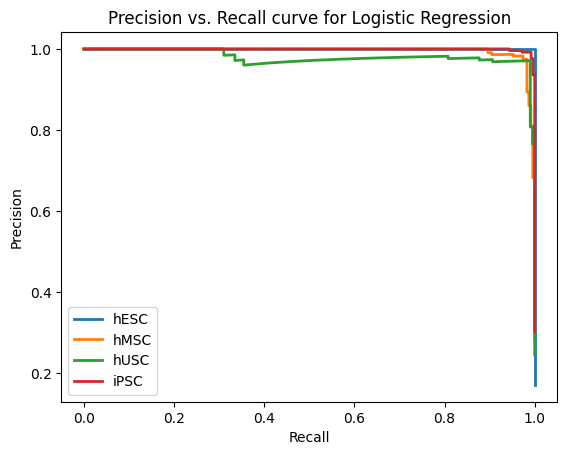

In [105]:
# precision recall curve
precision = dict()
recall = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_pr[:, i],
                                                        y_score_pr_lr[:, i])
    plt.plot(recall[i], precision[i], lw=2, label='{}'.format(label_encoder.classes_[i]))
    
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.title("Precision vs. Recall curve for Logistic Regression")
plt.show()

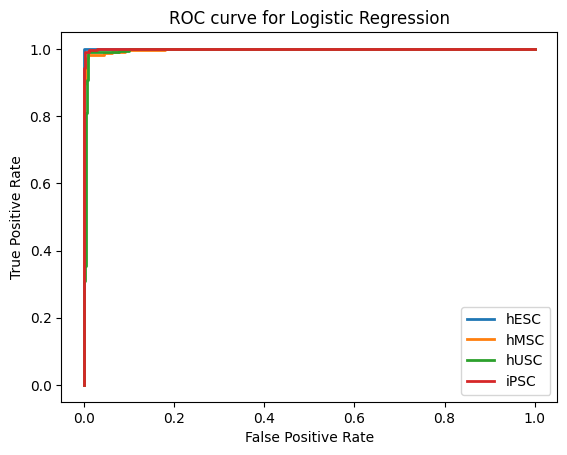

In [106]:
# roc curve
fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_pr[:, i],
                                  y_score_pr_lr[:, i])
    plt.plot(fpr[i], tpr[i], lw=2, label='{}'.format(label_encoder.classes_[i]))

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="best")
plt.title("ROC curve for Logistic Regression")
plt.show()

In [107]:
predictions = lrg.predict(X_temp)
accuracy = accuracy_score(y_temp, predictions)
b_accuracy = balanced_accuracy_score(y_temp, predictions) 
print(accuracy)
print(b_accuracy)
f1 = f1_score(y_temp, predictions, average='macro')
print(f1)

0.9757207890743551
0.9738314825271347
0.9749862507368654


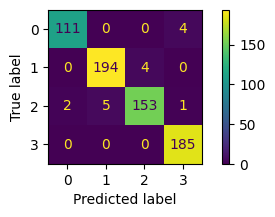

In [251]:
disp = ConfusionMatrixDisplay.from_predictions(y_temp, predictions)

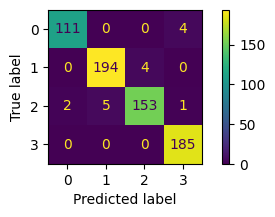

In [255]:
# type(disp)
disp.figure_

In [109]:
print(classification_report(y_temp, predictions))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       115
           1       0.97      0.98      0.98       198
           2       0.97      0.95      0.96       161
           3       0.97      1.00      0.99       185

    accuracy                           0.98       659
   macro avg       0.98      0.97      0.97       659
weighted avg       0.98      0.98      0.98       659



/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

## Cross Validation

In [154]:
X = df.iloc[:, :-1]
y = df['numeric_label']

skf = StratifiedKFold(n_splits=5, random_state=40, shuffle=True)

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    model = LogisticRegression(n_jobs=-1, multi_class='ovr')
#     print(train_index.shape)
#     print(test_index.shape)
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    b_accuracy = balanced_accuracy_score(y_test, predictions)
    f1score = f1_score(y_test, predictions, average='weighted')
    precision = precision_score(y_test, predictions, average='weighted')
    recall = recall_score(y_test, predictions, average='weighted')
    
    print(accuracy, end='\t')
    print(b_accuracy, end='\t')
    print(f1score, end='\t')
    print(precision, end='\t')
    print(recall)

0.9696509863429439	0.9718077840700541	0.9695933425133247	0.9701658529559319	0.9696509863429439
0.9742033383915023	0.9730605933311831	0.9741844590449181	0.9742102772848493	0.9742033383915023
0.9726858877086495	0.9712355613659209	0.9726680614669342	0.9727265397123761	0.9726858877086495
0.9772382397572079	0.9783575736160748	0.9774883573704002	0.9784615627043568	0.9772382397572079
0.9741641337386018	0.9710926163511174	0.9740966288662966	0.9744199504034987	0.9741641337386018


## Testing on Stemmapper data

In [ ]:
X_test, y_test = stmpr_data.iloc[:,:-1], stmpr_data['numeric_label']
predictions = lrg.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(accuracy)

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, predictions)

In [ ]:
print(classification_report(y_test, predictions))

## Testing on PCBC data

In [ ]:
pcbc_data = pd.read_csv('pcbc_final_data.csv')
pcbc_data.drop('Unnamed: 0', axis=1, inplace=True)
pcbc_data['numeric_label'] = label_encoder.transform(pcbc_data.label)
pcbc_data.drop('label', axis=1, inplace=True)
pcbc_data.sort_index(axis=1, inplace=True)
pcbc_data.head()

In [ ]:
pcbc_data.shape

In [ ]:
X_test, y_test = pcbc_data.iloc[:,:-1], pcbc_data['numeric_label']
predictions = lrg.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(accuracy)

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, predictions)

# SVM classifier

In [71]:
svc = LinearSVC()
svc.fit(X_train, y_train)

/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC()

In [77]:
import pickle
# save the model to disk
filename = 'svm_stemformatics.sav'
pickle.dump(svc, open(filename, 'wb'))
 
# load the model from disk
# filename = 'svm_stemformatics.sav'
# loaded_model = pickle.load(open(filename, 'rb'))

In [120]:
from sklearn.svm import SVC
svm_clf_pr = OneVsRestClassifier(SVC(kernel= 'linear', probability = True))
svm_clf_pr.fit(X_train_pr, y_train_pr)

y_score_pr_svm = svm_clf_pr.predict_proba(X_test_pr)

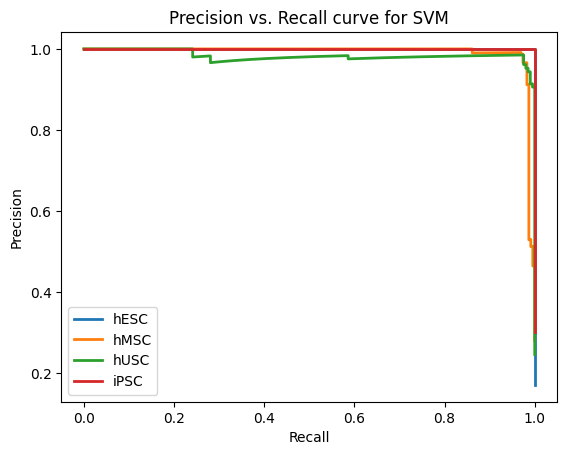

In [121]:
# precision recall curve
precision = dict()
recall = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_pr[:, i],
                                                        y_score_pr_svm[:, i])
    plt.plot(recall[i], precision[i], lw=2, label='{}'.format(label_encoder.classes_[i]))
    
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.title("Precision vs. Recall curve for SVM")
plt.show()

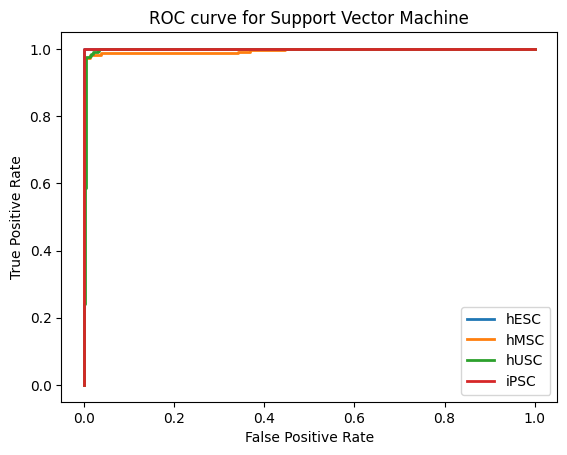

In [122]:
# roc curve
fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_pr[:, i],
                                  y_score_pr_svm[:, i])
    plt.plot(fpr[i], tpr[i], lw=2, label='{}'.format(label_encoder.classes_[i]))

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="best")
plt.title("ROC curve for Support Vector Machine")
plt.show()

In [72]:
predictions = svc.predict(X_temp)
accuracy = accuracy_score(y_temp, predictions)
b_accuracy = balanced_accuracy_score(y_temp, predictions) 
print(accuracy)
print(b_accuracy)

0.9802731411229135
0.9800222724135768


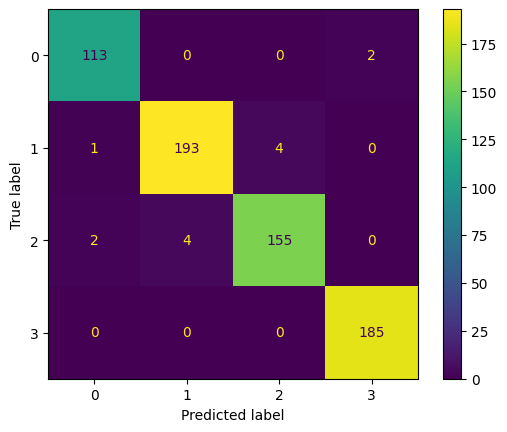

In [73]:
disp = ConfusionMatrixDisplay.from_predictions(y_temp, predictions)

In [15]:
print(classification_report(y_temp, predictions))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       115
           1       0.97      0.97      0.97       198
           2       0.97      0.96      0.97       161
           3       0.99      1.00      0.99       185

    accuracy                           0.98       659
   macro avg       0.98      0.98      0.98       659
weighted avg       0.98      0.98      0.98       659



## Cross-validation

In [155]:
X = df.iloc[:, :-1]
y = df['numeric_label']

skf = StratifiedKFold(n_splits=5, random_state=40, shuffle=True)

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    model = LinearSVC()
#     print(train_index.shape)
#     print(test_index.shape)
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    b_accuracy = balanced_accuracy_score(y_test, predictions)
    f1score = f1_score(y_test, predictions, average='weighted')
    precision = precision_score(y_test, predictions, average='weighted')
    recall = recall_score(y_test, predictions, average='weighted')
    
    print(accuracy, end='\t')
    print(b_accuracy, end='\t')
    print(f1score, end='\t')
    print(precision, end='\t')
    print(recall)

/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

0.9757207890743551	0.9779782785380945	0.9756787512635704	0.9761039556526067	0.9757207890743551


/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

0.9787556904400607	0.9779810877992237	0.9787556169387219	0.9787842996154197	0.9787556904400607


/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.9772382397572079	0.9754128810615512	0.9772108126694965	0.9773416473925344	0.9772382397572079


/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.9802731411229135	0.982160675565969	0.980423074179352	0.981203494187075	0.9802731411229135
0.9878419452887538	0.9870308756303146	0.9878226984413655	0.9878861674310676	0.9878419452887538


/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [26]:
# model = LogisticRegression()
scores = cross_val_score(model, X,y, cv=skf, scoring='accuracy')
print(scores)

/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[0.97572079 0.97875569 0.97723824 0.98027314 0.98784195]


/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


# Decision tree classifier

In [124]:
from sklearn import tree

In [ ]:
# train, test = train_test_split(df, test_size=0.2, random_state=55, shuffle=True)
# X_train, y_train = train.iloc[:, :-1], train['numeric_label']
# print(X_train.shape, y_train.shape)

In [ ]:
# X_temp, y_temp = test.iloc[:, :-1], test['numeric_label']
# X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size = 0.3, shuffle=False)
# print(X_test.shape, y_test.shape, X_val.shape, y_val.shape)
# print(X_temp.shape, y_temp.shape)

In [125]:
dt_clf = tree.DecisionTreeClassifier()

In [126]:
dt_clf = dt_clf.fit(X_train, y_train)

In [146]:
dt_clf_pr = OneVsRestClassifier(tree.DecisionTreeClassifier())
dt_clf_pr.fit(X_train_pr, y_train_pr)

y_score_pr_dt = dt_clf_pr.predict_proba(X_test_pr)

In [147]:
dt_clf_pr.predict_proba(X_test_pr)

array([[1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

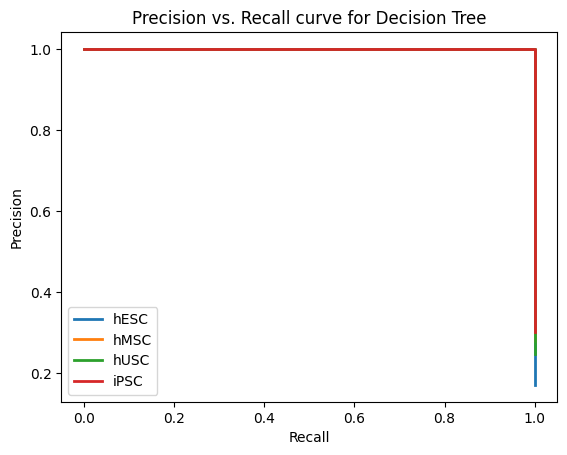

In [143]:
# precision recall curve
precision = dict()
recall = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_pr[:, i],
                                                        y_score_pr_dt[:, i])
    plt.plot(recall[i], precision[i], lw=2, label='{}'.format(label_encoder.classes_[i]))
    
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.title("Precision vs. Recall curve for Decision Tree")
plt.show()

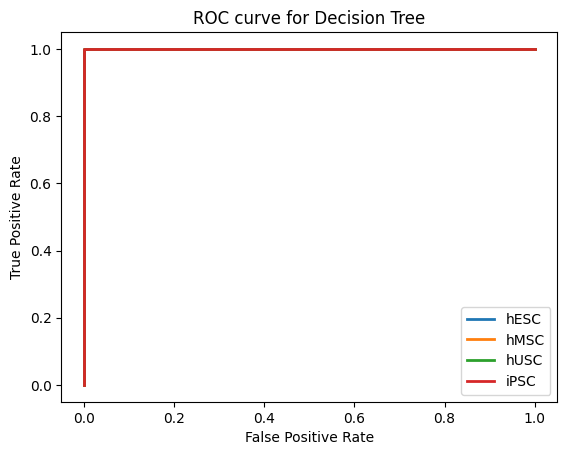

In [144]:
# roc curve
fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_pr[:, i],
                                  y_score_pr_dt[:, i])
    plt.plot(fpr[i], tpr[i], lw=2, label='{}'.format(label_encoder.classes_[i]))

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="best")
plt.title("ROC curve for Decision Tree")
plt.show()

In [131]:
dt_predictions = dt_clf.predict(X_temp)
dt_accuracy = accuracy_score(y_temp, dt_predictions)
dt_b_accuracy = balanced_accuracy_score(y_temp, dt_predictions) 
print(dt_accuracy)
print(dt_b_accuracy)
dt_f1 = f1_score(y_temp, dt_predictions, average='macro')
print(dt_f1)

0.849772382397572
0.845383455166064
0.8427373884604628


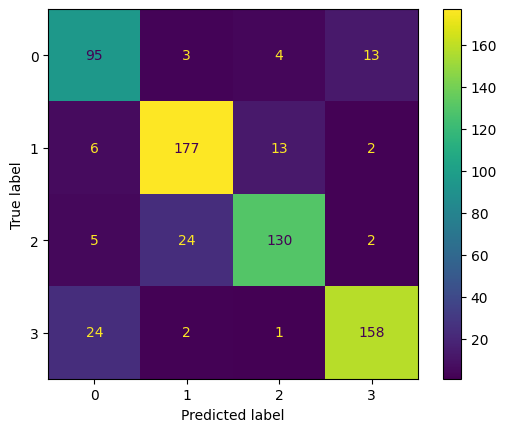

In [132]:
ConfusionMatrixDisplay.from_predictions(y_temp, dt_predictions)

In [133]:
print(classification_report(y_temp, dt_predictions))

              precision    recall  f1-score   support

           0       0.73      0.83      0.78       115
           1       0.86      0.89      0.88       198
           2       0.88      0.81      0.84       161
           3       0.90      0.85      0.88       185

    accuracy                           0.85       659
   macro avg       0.84      0.85      0.84       659
weighted avg       0.85      0.85      0.85       659



In [156]:
X = df.iloc[:, :-1]
y = df['numeric_label']

skf = StratifiedKFold(n_splits=5, random_state=40, shuffle=True)

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    model = tree.DecisionTreeClassifier()
#     print(train_index.shape)
#     print(test_index.shape)
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    b_accuracy = balanced_accuracy_score(y_test, predictions)
    f1score = f1_score(y_test, predictions, average='weighted')
    precision = precision_score(y_test, predictions, average='weighted')
    recall = recall_score(y_test, predictions, average='weighted')
    
    print(accuracy, end='\t')
    print(b_accuracy, end='\t')
    print(f1score, end='\t')
    print(precision, end='\t')
    print(recall)

0.8937784522003035	0.8906031540766949	0.8941393413012781	0.8951096895565741	0.8937784522003035
0.8679817905918058	0.8640280937830377	0.8674623059619856	0.8676738463995871	0.8679817905918058
0.8725341426403642	0.8639331063548914	0.8723035940063859	0.8726138264573164	0.8725341426403642
0.8922610015174507	0.8935446693643352	0.893232958357363	0.8966036845159918	0.8922610015174507
0.8936170212765957	0.8875810885612265	0.8935322238819109	0.8942608835057549	0.8936170212765957


In [ ]:
# tree.plot_tree(clf)

In [ ]:
# !pip install graphviz

In [28]:
import graphviz 
dot_data = tree.export_graphviz(dt_clf, out_file=None) 
graph = graphviz.Source(dot_data) 
graph.render("stmfr_dt")

# This pdf should have the tree as in the next cell. The pdf helps in better visualisation.

'stmfr_dt.pdf'

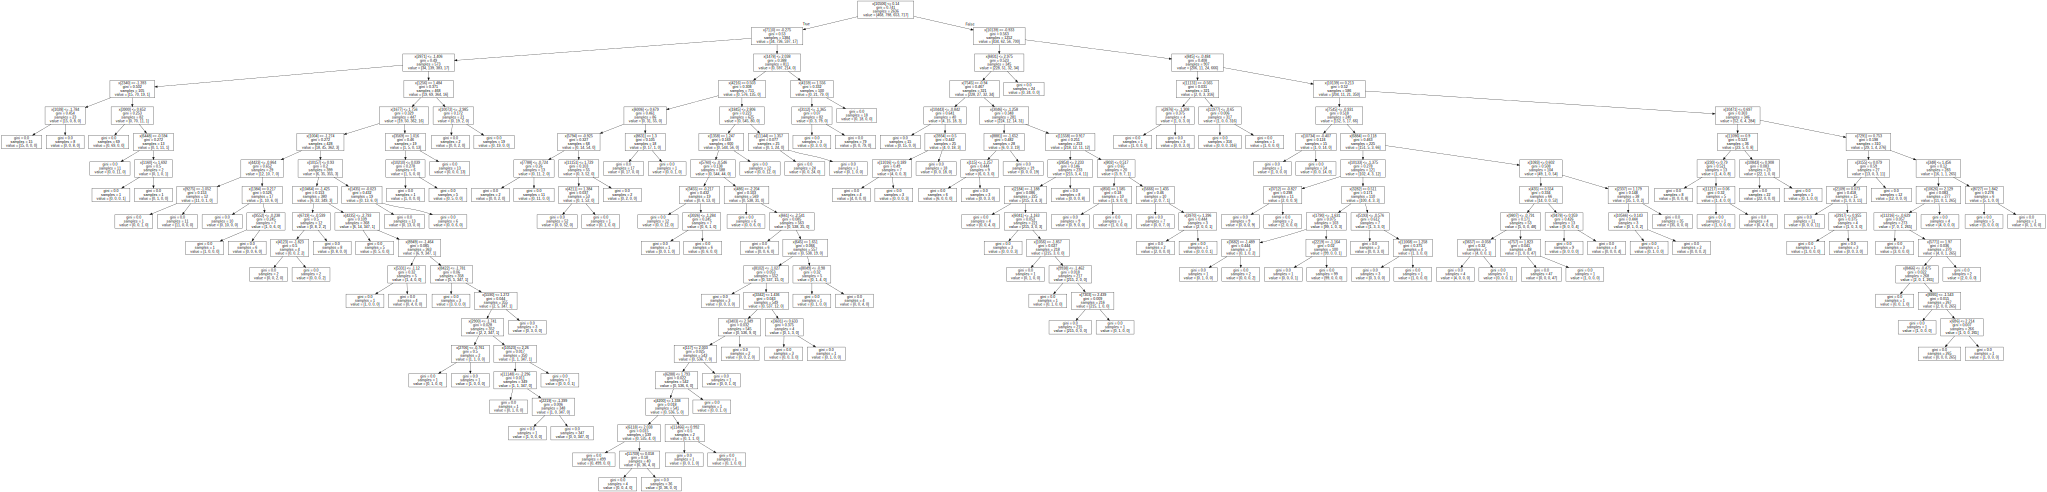

In [29]:
graph

In [30]:
from sklearn.tree import export_text
r = export_text(dt_clf)
print(r) # prints a text report showing the rules of a decision tree.

|--- feature_10506 <= 0.14
|   |--- feature_7110 <= -0.27
|   |   |--- feature_2871 <= -1.41
|   |   |   |--- feature_2340 <= -1.39
|   |   |   |   |--- feature_1028 <= -1.78
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_1028 >  -1.78
|   |   |   |   |   |--- class: 2
|   |   |   |--- feature_2340 >  -1.39
|   |   |   |   |--- feature_3900 <= 0.65
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_3900 >  0.65
|   |   |   |   |   |--- feature_6448 <= -0.59
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |--- feature_6448 >  -0.59
|   |   |   |   |   |   |--- feature_1160 <= 1.69
|   |   |   |   |   |   |   |--- class: 3
|   |   |   |   |   |   |--- feature_1160 >  1.69
|   |   |   |   |   |   |   |--- class: 1
|   |   |--- feature_2871 >  -1.41
|   |   |   |--- feature_1256 <= 1.48
|   |   |   |   |--- feature_1677 <= 1.76
|   |   |   |   |   |--- feature_1004 <= -1.27
|   |   |   |   |   |   |--- feature_4423 <= -0.86
|   |   |   |   |   |   |   

In [ ]:
type(r)

## Ensemble methods

In [17]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=10)
rf_clf = rf_clf.fit(X_train, y_train)

In [21]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.preprocessing import label_binarize

In [23]:
X = df.iloc[:, :-1]
y = df['numeric_label']
n_classes = len(set(y))
Y = label_binarize(df['numeric_label'], classes=[*range(n_classes)])
X_train_pr, X_test_pr, y_train_pr, y_test_pr = train_test_split(df,
                                                    Y,
                                                    random_state = 42)

In [ ]:
rf_clf_pr = OneVsRestClassifier(RandomForestClassifier(n_estimators=50,
                             max_depth=3,
                             random_state=0))
rf_clf_pr.fit(X_train_pr, y_train_pr)

y_score_pr_rf = rf_clf_pr.predict_proba(X_test_pr)

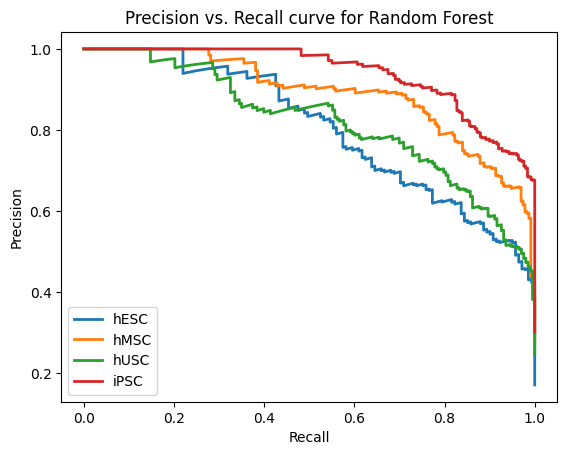

In [148]:
# precision recall curve
precision = dict()
recall = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_pr[:, i],
                                                        y_score_pr_rf[:, i])
    plt.plot(recall[i], precision[i], lw=2, label='{}'.format(label_encoder.classes_[i]))
    
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.title("Precision vs. Recall curve for Random Forest")
plt.show()

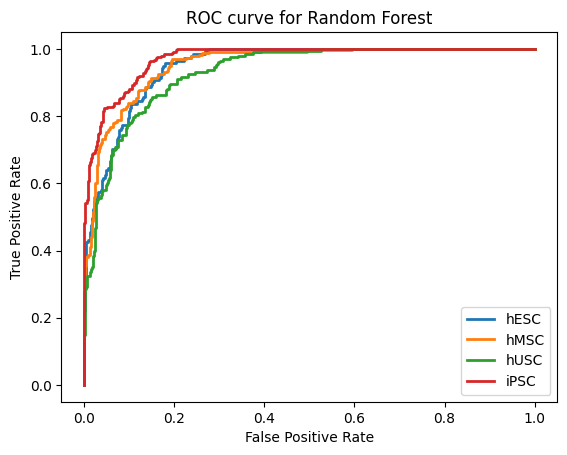

In [149]:
# roc curve
fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_pr[:, i],
                                  y_score_pr_rf[:, i])
    plt.plot(fpr[i], tpr[i], lw=2, label='{}'.format(label_encoder.classes_[i]))

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="best")
plt.title("ROC curve for Random Forest")
plt.show()

In [41]:
rf_predictions = rf_clf.predict(X_temp)
rf_accuracy = accuracy_score(y_temp, rf_predictions)
rf_b_accuracy = balanced_accuracy_score(y_temp, rf_predictions) 
print(rf_accuracy)
print(rf_b_accuracy)
rf_f1 = f1_score(y_temp, rf_predictions, average='macro')
print(rf_f1)

0.921092564491654
0.9168540788106005
0.9152341255690164


In [ ]:
rf_disp = ConfusionMatrixDisplay.from_predictions(y_temp, rf_predictions, display_labels = label_encoder.classes_, im_kw = df_results['precision'][0:4] )

In [ ]:
# recall = np.diag(cm) / np.sum(cm, axis = 1)
# precision = np.diag(cm) / np.sum(cm, axis = 0)

In [45]:
y_score

array([[0.3667255 , 0.06801059, 0.22019526, 0.28095013],
       [0.09888217, 0.34537653, 0.5349058 , 0.04849868],
       [0.39461664, 0.06488538, 0.15955263, 0.27869707],
       ...,
       [0.12251579, 0.0553198 , 0.05207418, 0.82457941],
       [0.1366602 , 0.05327288, 0.07661457, 0.68150479],
       [0.02754087, 0.81943735, 0.19445926, 0.0230783 ]])

In [46]:
y_test

array([[1, 0, 0, 0],
       [0, 0, 1, 0],
       [1, 0, 0, 0],
       ...,
       [0, 0, 0, 1],
       [0, 0, 0, 1],
       [0, 1, 0, 0]])

In [170]:
print(classification_report(y_temp, rf_predictions))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       115
           1       0.93      0.96      0.95       198
           2       0.95      0.89      0.92       161
           3       0.94      0.92      0.93       185

    accuracy                           0.92       659
   macro avg       0.92      0.92      0.92       659
weighted avg       0.92      0.92      0.92       659



In [189]:
t_temp = classification_report(y_temp, rf_predictions, output_dict=True)

In [197]:
df_results = pd.DataFrame(t_temp).transpose()

In [199]:
# type(df_results)
df_results

,precision,recall,f1-score,support
0,0.830645,0.895652,0.861925,115.000000
1,0.931707,0.964646,0.947891,198.000000
2,0.953333,0.888199,0.919614,161.000000
3,0.944444,0.918919,0.931507,185.000000
accuracy,0.921093,0.921093,0.921093,0.921093
macro avg,0.915033,0.916854,0.915234,659.000000
weighted avg,0.922930,0.921093,0.921381,659.000000


In [208]:
from sklearn.metrics import precision_score, recall_score
print(precision_score(y_temp, rf_predictions, average=None))
print(recall_score(y_temp, rf_predictions, average=None))

[0.83064516 0.93170732 0.95333333 0.94444444]
[0.89565217 0.96464646 0.88819876 0.91891892]


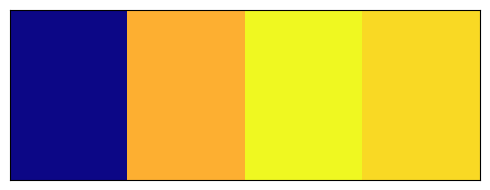

In [248]:
# plt.rcParams["figure.figsize"] = 5,2

# x = np.linspace(0, 4, 4)
y = precision_score(y_temp, rf_predictions, average=None)

fig, ax = plt.subplots(nrows=1, sharex=True)

# extent = [x[0]-(x[1]-x[0])/2., x[-1]+(x[1]-x[0])/2.,0,1]
# ax.imshow(y[np.newaxis,:], cmap="viridis", aspect="auto", extent=extent)
ax.imshow(y[np.newaxis,:], cmap="plasma", aspect="auto", data=y)
ax.set_yticks([])
ax.set_xticks([])
# ax.set_xlim(extent[0], extent[1])

# ax.plot(y)

precision_plt = plt.tight_layout()
plt.show()

In [213]:
type(precision_score(y_temp, rf_predictions, average=None))

numpy.ndarray

In [157]:
X = df.iloc[:, :-1]
y = df['numeric_label']

skf = StratifiedKFold(n_splits=5, random_state=40, shuffle=True)

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
#     print(train_index.shape)
#     print(test_index.shape)
    model = RandomForestClassifier(n_estimators=10)
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    b_accuracy = balanced_accuracy_score(y_test, predictions)
    f1score = f1_score(y_test, predictions, average='weighted')
    precision = precision_score(y_test, predictions, average='weighted')
    recall = recall_score(y_test, predictions, average='weighted')
    
    print(accuracy, end='\t')
    print(b_accuracy, end='\t')
    print(f1score, end='\t')
    print(precision, end='\t')
    print(recall)

0.9256449165402124	0.9226086047463331	0.9255550377284819	0.9259747821854561	0.9256449165402124
0.928679817905918	0.9233870432424087	0.9286697992412326	0.9287410963089735	0.928679817905918
0.9165402124430956	0.9105238457167403	0.916442564144158	0.9165513640665853	0.9165402124430956
0.9256449165402124	0.9224611534943872	0.9257562126609926	0.926477316904235	0.9256449165402124
0.9270516717325228	0.919949829514705	0.9268162468796315	0.9278364215072297	0.9270516717325228


# MLP Classifier

In [166]:
nn_clf = MLPClassifier(hidden_layer_sizes=[512, 256], solver='sgd', batch_size=256, max_iter=100)
nn_clf.fit(X_train, y_train)
nn_preds = nn_clf.predict(X_temp)
nn_accuracy = accuracy_score(y_temp, nn_preds)
nn_balanced_accuracy = balanced_accuracy_score(y_temp, nn_preds)
print(nn_accuracy)

0.9726858877086495


/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [150]:
nn_clf_pr = OneVsRestClassifier(MLPClassifier(hidden_layer_sizes=[512, 256], solver='sgd', batch_size=256, max_iter=100))

nn_clf_pr.fit(X_train_pr, y_train_pr)

y_score_pr_nn = nn_clf_pr.predict_proba(X_test_pr)

/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged ye

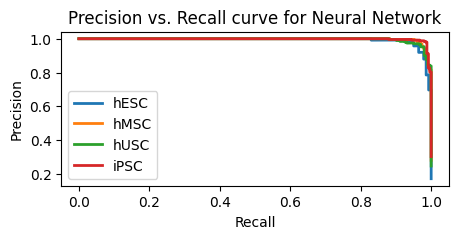

In [245]:
# precision recall curve
precision = dict()
recall = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_pr[:, i],
                                                        y_score_pr_nn[:, i])
    plt.plot(recall[i], precision[i], lw=2, label='{}'.format(label_encoder.classes_[i]))
    
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.title("Precision vs. Recall curve for Neural Network")
plt.show()

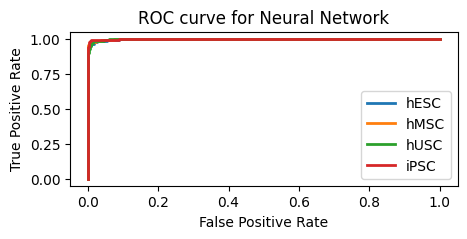

In [246]:
# roc curve
fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_pr[:, i],
                                  y_score_pr_nn[:, i])
    plt.plot(fpr[i], tpr[i], lw=2, label='{}'.format(label_encoder.classes_[i]))

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="best")
plt.title("ROC curve for Neural Network")
plt.show()

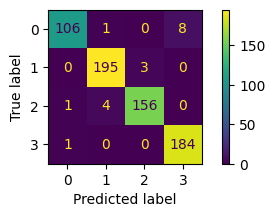

In [242]:
nn_disp = ConfusionMatrixDisplay.from_predictions(y_temp, nn_preds)

In [46]:
print(classification_report(y_temp, nn_preds))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       115
           1       0.97      0.98      0.98       198
           2       0.98      0.97      0.97       161
           3       0.97      0.99      0.98       185

    accuracy                           0.98       659
   macro avg       0.98      0.97      0.97       659
weighted avg       0.98      0.98      0.98       659



## Cross validation

In [158]:
X = df.iloc[:, :-1]
y = df['numeric_label']

skf = StratifiedKFold(n_splits=5, random_state=40, shuffle=True)

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
#     print(train_index.shape)
#     print(test_index.shape)
    model = MLPClassifier(hidden_layer_sizes=[512, 256], solver='sgd', batch_size=256, max_iter=100)
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    b_accuracy = balanced_accuracy_score(y_test, predictions)
    f1score = f1_score(y_test, predictions, average='weighted')
    precision = precision_score(y_test, predictions, average='weighted')
    recall = recall_score(y_test, predictions, average='weighted')
    
    print(accuracy, end='\t')
    print(b_accuracy, end='\t')
    print(f1score, end='\t')
    print(precision, end='\t')
    print(recall)

/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9650986342943855	0.964647869809641	0.9649967252021515	0.9651424588373536	0.9650986342943855


/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9757207890743551	0.9732771931497384	0.9757226566738615	0.9759701632143062	0.9757207890743551


/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9650986342943855	0.9607556871004851	0.9650430699449042	0.9654508134328692	0.9650986342943855


/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9817905918057663	0.9794246717305262	0.9818304185400297	0.981980856263366	0.9817905918057663


/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9604863221884499	0.9512555649638225	0.9601031642037834	0.9616822732454816	0.9604863221884499


In [ ]:
# scores = cross_val_score(model, X,y, cv=skf, scoring='f1')
# print(scores)
# print(np.mean(scores))

# Boosted Trees

In [ ]:
#Takes a lot of time to run

from sklearn.ensemble import AdaBoostClassifier

ab_clf = AdaBoostClassifier(n_estimators=100)
scores = cross_val_score(ab_clf, X_train, y_train, cv=5)
scores.mean()

AdaBoost takes a lot of time to train 

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,
                                 max_depth=1, random_state=0).fit(X_train, y_train)
gb_clf.score(X_temp, y_temp)

# Predicting on TCGA data

In [16]:
tcga_data = pd.read_csv('tcga_final_data.csv')
index = tcga_data.iloc[:, 0]
tcga_data.set_index(index, inplace=True)
tcga_data.drop('Unnamed: 0', axis=1, inplace=True)
tcga_data = tcga_data.transpose()
tcga_data.sort_index(inplace=True)
tcga_data = tcga_data.transpose()
tcga_data.head()

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266733,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
TCGA-4P-AA8J-01,-0.660760,-0.0516,-0.315193,-0.943822,-0.380364,-0.200853,-0.197779,-0.528666,-0.423831,-0.289101,...,0.0,-0.196144,0.556496,0.0,0.0,0.391311,0.0,-0.498943,0.0,1.504546
TCGA-BA-4074-01,0.734845,-0.0516,4.122519,-0.570718,1.866481,-0.293382,-0.174223,-0.374161,0.473098,-0.779825,...,0.0,-0.224913,-0.967386,0.0,0.0,-0.429786,0.0,-1.243142,0.0,-0.219662
TCGA-BA-4075-01,-0.137566,-0.0516,3.951437,-0.934663,0.550249,-0.225749,-0.246877,0.137983,0.155545,-0.494751,...,0.0,-0.327035,-1.524428,0.0,0.0,-0.634320,0.0,-1.261824,0.0,-0.156087
TCGA-BA-4076-01,-0.588152,-0.0516,0.275611,-0.589297,-0.137961,-0.329927,-0.321080,-0.158018,0.008967,-0.490037,...,0.0,-0.346863,-0.405294,0.0,0.0,-0.478480,0.0,-0.664333,0.0,-0.552089
TCGA-BA-4077-01,-0.590541,-0.0516,-0.603677,-0.350072,0.741167,-0.025565,-0.093639,-0.639857,0.363241,-0.244988,...,0.0,-0.332242,-0.669118,0.0,0.0,-0.369545,0.0,-1.071120,0.0,-0.471678


In [17]:
tcga_data.shape

(11070, 11980)

In [20]:
# predicting on LR 
# tcga_predictions = lrg.predict(tcga_data)
# pred_labels = label_encoder.inverse_transform(tcga_predictions) 

# predicting on SVM
tcga_predictions = svc.predict(tcga_data)                               
pred_labels = label_encoder.inverse_transform(tcga_predictions)

In [21]:
pd.Series(pred_labels).value_counts()

iPSC    3338
hUSC    2741
hMSC    2601
hESC    2390
dtype: int64

In [23]:
# tcga_predictions_lr = pd.DataFrame({'sample_id': tcga_data.index.tolist(), 'predicted_label':pred_labels})
# display(tcga_predictions_lr)
# tcga_predictions_lr.to_csv('tcga_predictions_lr_merged.csv')

tcga_predictions_svc = pd.DataFrame({'sample_id': tcga_data.index.tolist(), 'predicted_label':pred_labels})
display(tcga_predictions_svc)
tcga_predictions_svc.to_csv('tcga_predictions_svc_merged.csv')

,sample_id,predicted_label
0,TCGA-4P-AA8J-01,iPSC
1,TCGA-BA-4074-01,iPSC
2,TCGA-BA-4075-01,iPSC
3,TCGA-BA-4076-01,iPSC
4,TCGA-BA-4077-01,iPSC
...,...,...
11065,TCGA-AG-A02G-01,hESC
11066,TCGA-AG-A02N-01,hESC
11067,TCGA-AG-A02X-01,iPSC
11068,TCGA-AG-A032-01,iPSC


In [28]:
lr_predictions_df = pd.read_csv('tcga_predictions_lr_merged.csv')
svc_predictions_df = pd.read_csv('tcga_predictions_svc_merged.csv')

lr_predictions = lr_predictions_df['predicted_label']
svc_predictions = svc_predictions_df['predicted_label']

# agreement rate between LR and SVC predictions
np.where(lr_predictions == svc_predictions)[0].shape

(8519,)

In [84]:
coefs = lrg.coef_
coefs = coefs.transpose()
print(coefs.shape)
coefs_df = pd.DataFrame(coefs)
print(coefs_df.shape)
coefs_df.to_csv('coefs_new.csv')

(11980, 4)
(11980, 4)


In [94]:
len(lrg.coef_[0])

11980

# Norm, distance from the plane (Stemness score)

In [166]:
norms = []
for coef in lrg.coef_:
    norms.append(np.linalg.norm(coef))
#     print(norms)

In [205]:
# lrg.decision_function(tcga_data.iloc[1, :].to_numpy().reshape(1, -1))
z_values_4_class = lrg.decision_function(tcga_data)
print(z_values_4_class.shape)
pd.DataFrame(z_values_4_class).to_csv("z_values_4_class.csv")

(11070, 4)


In [175]:
# z_values_4_class = z_values_4_class.transpose()

In [206]:
z_values_4_class=pd.DataFrame(z_values_4_class)

In [209]:
# type(z_values_4_class)
z_values_4_class.shape

(11070, 4)

In [180]:
distance_df = pd.DataFrame() 
distance_0 = z_values_4_class[0]/norms[0]
distance_1 = z_values_4_class[1]/norms[1]
distance_2 = z_values_4_class[2]/norms[2]
distance_3 = z_values_4_class[3]/norms[3]

distance_df['hESC'] = distance_0
distance_df['hMSC'] = distance_1
distance_df['hUSC'] = distance_2
distance_df['iPSC'] = distance_3

In [208]:
distance_df

,hESC,hMSC,hUSC,iPSC,stemness_score
0,-2.021731,-0.560042,-1.728033,0.376469,0.376469
1,-6.332032,1.293370,-2.026114,1.812329,1.812329
2,-3.989468,-0.272543,-2.038866,-0.546593,-0.272543
3,-2.306271,-0.376492,-1.317583,-0.632803,-0.376492
4,-0.096042,-1.412817,-1.108706,-0.476905,-0.096042
...,...,...,...,...,...
11065,0.113570,-0.434697,-1.908903,-0.862523,0.113570
11066,0.711870,0.051627,-2.815806,-0.503993,0.711870
11067,0.833009,-0.049203,-4.101841,1.283088,1.283088
11068,-1.103169,-0.259758,-1.969474,1.131955,1.131955


In [182]:
distance_df['stemness_score'] = distance_df.max(axis=1)

In [183]:
distance_df

,hESC,hMSC,hUSC,iPSC,stemness_score
0,-2.021731,-0.560042,-1.728033,0.376469,0.376469
1,-6.332032,1.293370,-2.026114,1.812329,1.812329
2,-3.989468,-0.272543,-2.038866,-0.546593,-0.272543
3,-2.306271,-0.376492,-1.317583,-0.632803,-0.376492
4,-0.096042,-1.412817,-1.108706,-0.476905,-0.096042
...,...,...,...,...,...
11065,0.113570,-0.434697,-1.908903,-0.862523,0.113570
11066,0.711870,0.051627,-2.815806,-0.503993,0.711870
11067,0.833009,-0.049203,-4.101841,1.283088,1.283088
11068,-1.103169,-0.259758,-1.969474,1.131955,1.131955


In [187]:
def compute_soft_max(row):
    denom = sum([np.exp(i) for i in row])
    probs = [np.exp(i)/denom for i in row]
    return probs

In [214]:
row = [-11.814005,-2.313928,-7.298420,1.823137]
compute_soft_max(row)
# row = [-11.8140054,-2.313928442,-11.81641105,-2.394080195,1.823136538]

[1.1763499014686e-06,
 0.015716923496237736,
 0.00010755489199829769,
 0.9841743452618624]

In [225]:
prob_score = z_values_4_class.apply(compute_soft_max,axis=1, result_type='expand')

In [227]:
prob_score.columns = ['hESC_prob','hMSC_prob','hUSC_prob','iPSC_prob']

In [228]:
prob_score

,hESC_prob,hMSC_prob,hUSC_prob,iPSC_prob
0,1.176350e-06,0.015717,1.075550e-04,0.984174
1,1.273807e-20,0.031287,2.871710e-08,0.968713
2,1.899007e-10,0.820297,4.604718e-04,0.179242
3,5.364476e-06,0.806908,1.464201e-02,0.178445
4,8.365377e-01,0.004277,1.356954e-02,0.145616
...,...,...,...,...
11065,9.144729e-01,0.078152,1.484312e-04,0.007226
11066,9.797373e-01,0.018930,1.046163e-07,0.001332
11067,2.062677e-01,0.001295,4.748618e-11,0.792438
11068,6.592642e-06,0.001421,1.014281e-06,0.998571


In [234]:
# distance_df
tcga_stemness_score_4class = pd.concat([distance_df, prob_score], axis=1)

In [238]:
tcga_stemness_score_4class.columns=['hESC_distance', 'hMSC_distance', 'hUSC_distance', 'iPSC_distance', 'stemness_score', 'hESC_prob',
       'hMSC_prob', 'hUSC_prob', 'iPSC_prob']

In [240]:
# tcga_stemness_score_4class.columns
tcga_stemness_score_4class.to_csv("tcga_measurements.csv")

In [223]:
z_values_4_class

,0,1,2,3
0,-11.814005,-2.313928,-7.298420,1.823137
1,-37.001300,5.343826,-8.557381,8.776605
2,-23.312500,-1.126069,-8.611239,-2.646997
3,-13.476721,-1.555555,-5.564870,-3.064487
4,-0.561223,-5.837345,-4.682667,-2.309520
...,...,...,...,...
11065,0.663647,-1.796042,-8.062334,-4.176956
11066,4.159818,0.213306,-11.892678,-2.440698
11067,4.867699,-0.203292,-17.324303,6.213638
11068,-6.446383,-1.073242,-8.318157,5.481744


In [211]:
z_values_4_class

,0,1,2,3
0,-11.814005,-2.313928,-7.298420,1.823137
1,-37.001300,5.343826,-8.557381,8.776605
2,-23.312500,-1.126069,-8.611239,-2.646997
3,-13.476721,-1.555555,-5.564870,-3.064487
4,-0.561223,-5.837345,-4.682667,-2.309520
...,...,...,...,...
11065,0.663647,-1.796042,-8.062334,-4.176956
11066,4.159818,0.213306,-11.892678,-2.440698
11067,4.867699,-0.203292,-17.324303,6.213638
11068,-6.446383,-1.073242,-8.318157,5.481744


In [ ]:
# difference in probability scores

# probas = lrg.predict_proba(tcga_data)
# predictions = lrg.predict(tcga_data)
# probas_list = []
# for i in probas:
# #     print(i)
#     max_proba = max(i)
#     i = np.delete(i, np.argmax(i))
#     res = max_proba - np.sum(i)
#     probas_list.append(res)

In [ ]:
# pd.Series(label_encoder.inverse_transform(predictions)).value_counts()

In [ ]:
# probability_diff = pd.DataFrame({'sample':tcga_data.index.to_list(), 'probability_difference':probas_list, 'label':label_encoder.inverse_transform(predictions)})
# probability_diff
# probability_diff.to_csv('probability_difference_values.csv')

In [ ]:
# raw output of logistic regression hypothesis function [h_w(x) values]
coefs = lrg.coef_
intercept = lrg.intercept_
np.dot(tcga_data, coefs[0]) + intercept[0]

In [ ]:
for coef in coefs:
    print(np.linalg.norm(coef))

(11070, 4)


In [163]:
type(distances)

numpy.ndarray

In [ ]:
# len(np.max(distances, axis=1))
mylist = []
count = 0
for i in(distances):
    in_count = 0
    for j in range(5):
        if i[j] > 0:
            continue
        else:
#             print(i[j])
            in_count+=1
            mylist.append(i[j])
#     if in_count > 1:
#         print(in_count)
    if in_count == 5:
        print(i)
        count+=1
    
print(count)
            
#     if not pd.Series(i).any()
#         pass
#     else:
#         count+=1
#     print(np.max(np.max(distances, axis=i))), 
#     print(np.min(np.max(distances, axis=i)))

In [ ]:
print(np.mean(mylist))

In [ ]:
print(tcga_predictions)

In [89]:
lrg.classes_

array([0, 1, 2, 3])